In [ ]:
import pandas as pd

df = pd.read_csv('/content/simplelinearregression.csv')
display(df.head())

,Age,Premium
0,18,10000
1,22,15000
2,23,18000
3,26,21000
4,28,24000


## Análisis Exploratorio de Datos (EDA)

In [ ]:
# Información general del DataFrame: tipos de datos y valores no nulos
print('Información del DataFrame:')
df.info()

Información del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Age      7 non-null      int64
 1   Premium  7 non-null      int64
dtypes: int64(2)
memory usage: 244.0 bytes


In [ ]:
# Estadísticas descriptivas de las columnas numéricas
print('\nEstadísticas descriptivas:')
display(df.describe())


Estadísticas descriptivas:


,Age,Premium
count,7.000000,7.000000
mean,25.857143,20214.285714
std,5.273474,6283.955382
min,18.000000,10000.000000
25%,22.500000,16500.000000
50%,26.000000,21000.000000
75%,29.500000,25250.000000
max,33.000000,27000.000000


In [ ]:
# Comprobar valores nulos
print('\nValores nulos por columna:')
display(df.isnull().sum())


Valores nulos por columna:


,0
Age,0
Premium,0


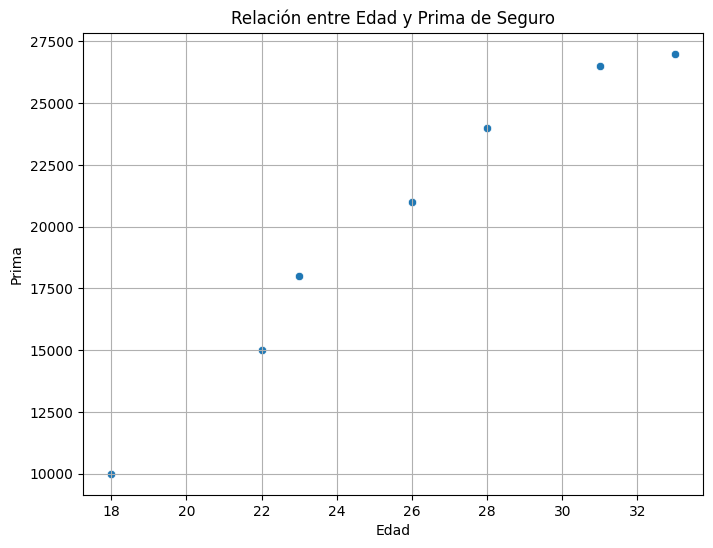

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualizar la relación entre 'Age' y 'Premium'
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Age', y='Premium', data=df)
plt.title('Relación entre Edad y Prima de Seguro')
plt.xlabel('Edad')
plt.ylabel('Prima')
plt.grid(True)
plt.show()

## Modelo de Regresión Lineal Simple

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
import numpy as np

# Preparar los datos
X = df['Age'].values.reshape(-1, 1) # Variable independiente (Edad)
y = df['Premium'].values.reshape(-1, 1) # Variable dependiente (Prima)

# Dividir los datos en conjuntos de entrenamiento y prueba (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

print(f"Tamaño del conjunto de entrenamiento: {len(X_train)} muestras")
print(f"Tamaño del conjunto de prueba: {len(X_test)} muestras")

Tamaño del conjunto de entrenamiento: 5 muestras
Tamaño del conjunto de prueba: 2 muestras


In [ ]:
# Entrenar el modelo de Regresión Lineal
regressor = LinearRegression()
regressor.fit(X_train, y_train)

# Mostrar el coeficiente (slope) y el intercepto
print(f"Coeficiente (m): {regressor.coef_[0][0]:.2f}")
print(f"Intercepto (b): {regressor.intercept_[0]:.2f}")

Coeficiente (m): 1317.31
Intercepto (b): -13632.69


In [ ]:
# Realizar predicciones con el conjunto de prueba
y_pred = regressor.predict(X_test)

# Mostrar las predicciones y los valores reales
predictions_df = pd.DataFrame({'Real': y_test.flatten(), 'Predicción': y_pred.flatten()})
display(predictions_df)

,Real,Predicción
0,27000,29838.461538
1,18000,16665.384615


In [ ]:
# Evaluar el modelo
print('Métricas de evaluación del modelo:')
print(f'Error Absoluto Medio (MAE): {metrics.mean_absolute_error(y_test, y_pred):.2f}')
print(f'Error Cuadrático Medio (MSE): {metrics.mean_squared_error(y_test, y_pred):.2f}')
print(f'Raíz del Error Cuadrático Medio (RMSE): {np.sqrt(metrics.mean_squared_error(y_test, y_pred)):.2f}')
print(f'R^2 Score: {metrics.r2_score(y_test, y_pred):.2f}')

Métricas de evaluación del modelo:
Error Absoluto Medio (MAE): 2086.54
Error Cuadrático Medio (MSE): 4919031.07
Raíz del Error Cuadrático Medio (RMSE): 2217.89
R^2 Score: 0.76


In [ ]:
from sklearn.metrics import mean_absolute_percentage_error

# Calcular MAPE
mape = mean_absolute_percentage_error(y_test, y_pred)

print(f'Error Porcentual Absoluto Medio (MAPE): {mape:.2%}')

Error Porcentual Absoluto Medio (MAPE): 8.96%


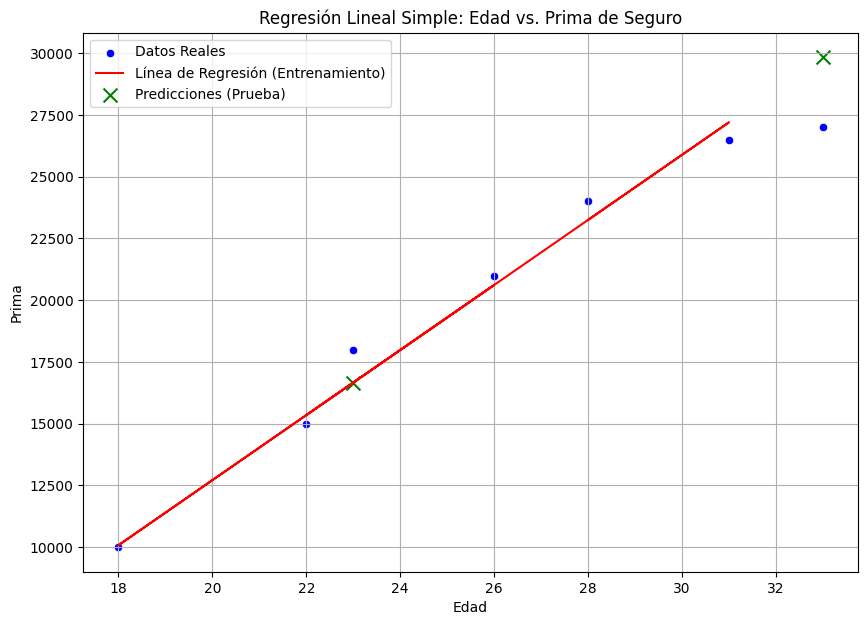

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualizar los resultados del entrenamiento y la línea de regresión
plt.figure(figsize=(10, 7))
sns.scatterplot(x=X.flatten(), y=y.flatten(), color='blue', label='Datos Reales')
plt.plot(X_train, regressor.predict(X_train), color='red', label='Línea de Regresión (Entrenamiento)')
plt.scatter(X_test, y_pred, color='green', marker='x', s=100, label='Predicciones (Prueba)')
plt.title('Regresión Lineal Simple: Edad vs. Prima de Seguro')
plt.xlabel('Edad')
plt.ylabel('Prima')
plt.legend()
plt.grid(True)
plt.show()

## Realizar Predicciones con el Modelo

In [ ]:
#@title Introduce una edad para predecir la prima
age_to_predict = 30 #@param {type:"number", min:1, max:100, step:1}

# Asegurarse de que la entrada sea un array 2D para el modelo
input_age = np.array([[age_to_predict]])

# Realizar la predicción
predicted_premium = regressor.predict(input_age)

print(f"Para una edad de {age_to_predict} años, la prima de seguro predicha es: {predicted_premium[0][0]:.2f}")

Para una edad de 30 años, la prima de seguro predicha es: 25886.54
